## CELL 1: Import Libraries

In [2]:
# Numerical computations
import numpy as np

# Data handling
import pandas as pd

# Preprocessing tools
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Random module for GA
import random

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## CELL 2: Load Dataset

In [5]:
# Load UNSW-NB15 training and test datasets (ensure parquet files are in your folder)
data      = pd.read_parquet('UNSW_NB15_training-set.parquet')   # training dataset
data_test = pd.read_parquet('UNSW_NB15_testing-set.parquet')    # test dataset

# View first rows of training data
data.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [ ]:
print(data['attack_cat'].unique())

## CELL 3: Preprocessing — Training Dataset

In [7]:
# ── Training dataset preprocessing ─────────────────────────────────────────

# Drop unnecessary columns if present
if 'id' in data.columns:
    data.drop(['id'], axis=1, inplace=True)

# Separate target
y_train_full = data['label']
X_train_full = data.drop('label', axis=1)

# Remove leakage-prone column
if 'attack_cat' in X_train_full.columns:
    X_train_full = X_train_full.drop('attack_cat', axis=1)

# Encode categorical columns
non_numeric_cols = [col for col in X_train_full.columns
                    if not pd.api.types.is_numeric_dtype(X_train_full[col])]

label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    X_train_full[col] = le.fit_transform(X_train_full[col])
    label_encoders[col] = le          # save encoder for reuse on test set

# Scale features — fit ONLY on training data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_full.values)

# Carve out a small validation split (15 %) for GA fitness evaluation
from sklearn.model_selection import train_test_split

X_train_arr, X_val_arr, y_train_arr, y_val_arr = train_test_split(
    X_train_scaled, y_train_full.values,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full.values
)

print("Training samples   :", X_train_arr.shape[0])
print("Validation samples :", X_val_arr.shape[0])

Training samples   : 149039
Validation samples : 26302


## CELL 4: Preprocessing — Test Dataset

In [9]:
# ── Test dataset preprocessing ──────────────────────────────────────────────

# Drop unnecessary columns if present
if 'id' in data_test.columns:
    data_test.drop(['id'], axis=1, inplace=True)

# Separate target
y_test = data_test['label'].values
X_test_raw = data_test.drop('label', axis=1)

# Remove leakage-prone column
if 'attack_cat' in X_test_raw.columns:
    X_test_raw = X_test_raw.drop('attack_cat', axis=1)

# Apply the SAME encoders fitted on training data
for col in non_numeric_cols:
    if col in X_test_raw.columns:
        le = label_encoders[col]
        # Handle unseen labels gracefully
        X_test_raw[col] = X_test_raw[col].map(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

# Apply the SAME scaler fitted on training data
X_test_scaled = scaler.transform(X_test_raw.values)

print("Test samples       :", X_test_scaled.shape[0])
print("Train label dist   :", pd.Series(y_train_arr).value_counts().to_dict())
print("Test  label dist   :", pd.Series(y_test).value_counts().to_dict())

Test samples       : 82332
Train label dist   : {1: 101439, 0: 47600}
Test  label dist   : {1: 45332, 0: 37000}


## CELL 5: Baseline Model (NO GA) — Trained on Training Dataset, Evaluated on Test Dataset

In [10]:
# ── Build baseline model ────────────────────────────────────────────────────
def create_baseline_model(input_dim, learning_rate=0.001, neurons=64, dropout_rate=0.3):
    model = Sequential()
    model.add(Dense(neurons,     input_dim=input_dim, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(neurons // 2,                    activation='relu'))
    model.add(Dense(1,                               activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = create_baseline_model(input_dim=X_train_arr.shape[1])

# Train
baseline_model.fit(
    X_train_arr, y_train_arr,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_arr, y_val_arr),
    verbose=1
)

# Evaluate on TEST dataset
baseline_preds = (baseline_model.predict(X_test_scaled) > 0.5).astype("int32")

print("\n=== Baseline Model — Test Dataset Results ===")
print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

Epoch 1/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8931 - loss: 0.2586 - val_accuracy: 0.9316 - val_loss: 0.1774
Epoch 2/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9283 - loss: 0.1787 - val_accuracy: 0.9332 - val_loss: 0.1647
Epoch 3/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9306 - loss: 0.1685 - val_accuracy: 0.9348 - val_loss: 0.1578
Epoch 4/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9318 - loss: 0.1617 - val_accuracy: 0.9361 - val_loss: 0.1536
Epoch 5/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9324 - loss: 0.1569 - val_accuracy: 0.9358 - val_loss: 0.1478
Epoch 6/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9329 - loss: 0.1523 - val_accuracy: 0.9364 - val_loss: 0.1457
Epoch 7/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9334 - loss: 0.1485 - val_accuracy: 0.9373 - val_loss: 0.1414
Epoch 8/20
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9338 - loss: 0.1464 - 

## CELL 6: GA Setup — Feature Selection + Hyperparameter Optimisation

In [22]:
# ── Parameter search space ───────────────────────────────────────────────────
# NOTE: "epochs" removed — GA should not search it; it is fixed inside fitness()
param_space = {
    "learning_rate": [0.0005, 0.001, 0.002],
    "neurons":       [32, 64, 128],       # removed 256 — too slow to evaluate
    "dropout":       [0.2, 0.3, 0.4],
    "batch_size":    [64, 128],           # larger batch = fewer steps per epoch
}

num_features = X_train_arr.shape[1]

# ── Create individual ────────────────────────────────────────────────────────
def create_individual():
    feature_mask = np.random.randint(0, 2, num_features)
    # Enforce a minimum of 50 % features selected to preserve enough signal
    while feature_mask.sum() < max(5, num_features // 2):
        feature_mask = np.random.randint(0, 2, num_features)
    return {
        "features":      feature_mask,
        "learning_rate": random.choice(param_space["learning_rate"]),
        "neurons":       random.choice(param_space["neurons"]),
        "dropout":       random.choice(param_space["dropout"]),
        "batch_size":    random.choice(param_space["batch_size"]),
    }

print("Individual structure created.")
print(f"Number of features in search space: {num_features}")

Individual structure created.
Number of features in search space: 34


## CELL 7: Fitness Function — Evaluated on Validation Split

In [24]:
def fitness(individual):
    mask = individual["features"]
    X_tr = X_train_arr[:, mask == 1]
    X_va = X_val_arr[:,   mask == 1]

    model = Sequential()
    model.add(Dense(individual["neurons"],      input_dim=X_tr.shape[1], activation='relu'))
    model.add(Dropout(individual["dropout"]))
    model.add(Dense(individual["neurons"] // 2,                          activation='relu'))
    model.add(Dense(1,                                                   activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=individual["learning_rate"]),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # ✅ Fixed low epoch count — 5 is enough to rank individuals relatively.
    # Full training happens only once in Cell 9 on the best individual.
    model.fit(
        X_tr, y_train_arr,
        epochs=5,
        batch_size=individual["batch_size"],
        verbose=0
    )

    preds = (model.predict(X_va, verbose=0) > 0.5).astype("int32")
    return accuracy_score(y_val_arr, preds)

## CELL 8: Run Genetic Algorithm

In [25]:
population_size = 6
generations     = 3
elite_size      = 2          # top individuals preserved each generation

# ── Crossover helper ─────────────────────────────────────────────────────────
def crossover(parent_a, parent_b):
    child = {}
    # Feature mask: single-point crossover
    point = random.randint(1, num_features - 1)
    child["features"] = np.concatenate([
        parent_a["features"][:point],
        parent_b["features"][point:]
    ])
    # Ensure minimum feature requirement
    if child["features"].sum() < max(5, num_features // 2):
        child["features"] = parent_a["features"].copy()

    # Hyperparameters: randomly inherit from either parent
    for key in ["learning_rate", "neurons", "dropout", "batch_size"]:
        child[key] = random.choice([parent_a[key], parent_b[key]])
    return child

# ── Mutation helper ───────────────────────────────────────────────────────────
def mutate(individual, mutation_rate=0.15):
    child = individual.copy()
    child["features"] = individual["features"].copy()

    # Flip bits in feature mask
    for i in range(num_features):
        if random.random() < mutation_rate:
            child["features"][i] = 1 - child["features"][i]

    # Ensure minimum features
    if child["features"].sum() < max(5, num_features // 2):
        child["features"] = individual["features"].copy()

    # Mutate a random hyperparameter
    if random.random() < 0.5:
        key = random.choice(list(param_space.keys()))
        child[key] = random.choice(param_space[key])

    return child

# ── Run GA ────────────────────────────────────────────────────────────────────
np.random.seed(42)
random.seed(42)

population = [create_individual() for _ in range(population_size)]
best_per_gen = []

for gen in range(generations):
    print(f"\n── Generation {gen + 1} / {generations} ──")

    scores = [(ind, fitness(ind)) for ind in population]
    scores.sort(key=lambda x: x[1], reverse=True)

    best_acc = scores[0][1]
    best_per_gen.append(best_acc)
    print(f"  Best Validation Accuracy: {best_acc:.4f}")

    # Elite selection
    new_population = [ind for ind, _ in scores[:elite_size]]

    # Crossover + mutation to fill the rest
    while len(new_population) < population_size:
        pa, pb = random.sample(new_population[:elite_size], 2)
        child  = crossover(pa, pb)
        child  = mutate(child)
        new_population.append(child)

    population = new_population

best_individual = scores[0][0]

print("\n=== GA Complete ===")
print(f"Best Validation Accuracy across all generations: {max(best_per_gen):.4f}")
print(f"Hyperparameters — LR: {best_individual['learning_rate']}, "
      f"Neurons: {best_individual['neurons']}, "
      f"Dropout: {best_individual['dropout']}, "
      f"Batch: {best_individual['batch_size']}")
print(f"Features selected: {best_individual['features'].sum()} / {num_features}")


── Generation 1 / 3 ──
  Best Validation Accuracy: 0.9355

── Generation 2 / 3 ──
  Best Validation Accuracy: 0.9367

── Generation 3 / 3 ──
  Best Validation Accuracy: 0.9376

=== GA Complete ===
Best Validation Accuracy across all generations: 0.9376
Hyperparameters — LR: 0.002, Neurons: 128, Dropout: 0.4, Batch: 64
Features selected: 24 / 34


## CELL 9: Train Hybrid Model (GA-Optimised) — Evaluated on Test Dataset

In [28]:
mask = best_individual["features"]

X_tr_sel   = X_train_arr[:, mask == 1]
X_te_sel   = X_test_scaled[:, mask == 1]

# Build final hybrid model using GA-discovered architecture
hybrid_model = Sequential()
hybrid_model.add(Dense(best_individual["neurons"],      input_dim=X_tr_sel.shape[1], activation='relu'))
hybrid_model.add(Dropout(best_individual["dropout"]))
hybrid_model.add(Dense(best_individual["neurons"] // 2,                              activation='relu'))
hybrid_model.add(Dense(1,                                                            activation='sigmoid'))

hybrid_model.compile(
    optimizer=Adam(learning_rate=best_individual["learning_rate"]),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train on full training data (train + val) with the GA-discovered epoch count
X_full_train = np.vstack([X_train_arr[:, mask == 1], X_val_arr[:, mask == 1]])
y_full_train  = np.concatenate([y_train_arr, y_val_arr])

hybrid_model.fit(
    X_full_train, y_full_train,
    epochs=20,
    batch_size=best_individual["batch_size"],
    verbose=1
)

# Predict on TEST dataset
hybrid_preds = (hybrid_model.predict(X_te_sel, verbose=0) > 0.5).astype("int32")

Epoch 1/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9112 - loss: 0.2191
Epoch 2/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9297 - loss: 0.1675
Epoch 3/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9310 - loss: 0.1598
Epoch 4/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9323 - loss: 0.1549
Epoch 5/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9329 - loss: 0.1530
Epoch 6/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9337 - loss: 0.1503
Epoch 7/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9338 - loss: 0.1490
Epoch 8/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9346 - loss: 0.1479
Epoch 9/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9341 - loss: 0.1465
Epoch 10/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9349 - loss: 0.1451
Epoch 11/20
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9350 - loss: 0.1449
Epoch 12/20
2740/2740 ━━━━━━━━

## CELL 10: Evaluation Metrics — Hybrid Model on Test Dataset

In [29]:
print("=== Hybrid Model (GA-Optimised) — Test Dataset Results ===")
print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_preds))
print(classification_report(y_test, hybrid_preds))

=== Hybrid Model (GA-Optimised) — Test Dataset Results ===
Hybrid Accuracy: 0.8255113443132682
              precision    recall  f1-score   support

           0       0.97      0.63      0.76     37000
           1       0.77      0.99      0.86     45332

    accuracy                           0.83     82332
   macro avg       0.87      0.81      0.81     82332
weighted avg       0.86      0.83      0.82     82332



## CELL 11: Confusion Matrix — Hybrid Model

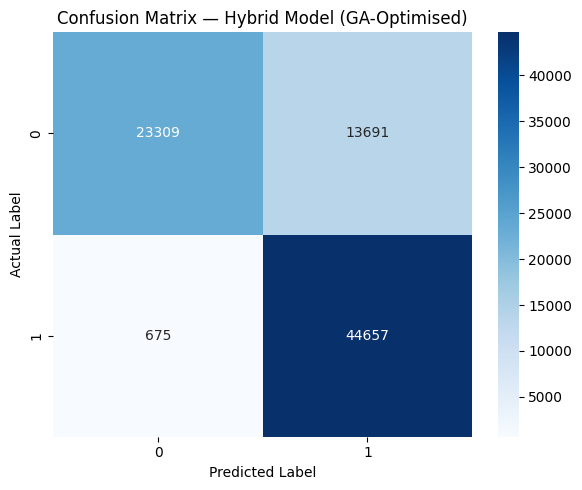

In [30]:
cm = confusion_matrix(y_test, hybrid_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Hybrid Model (GA-Optimised)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

## CELL 12: ROC Curve — Hybrid Model

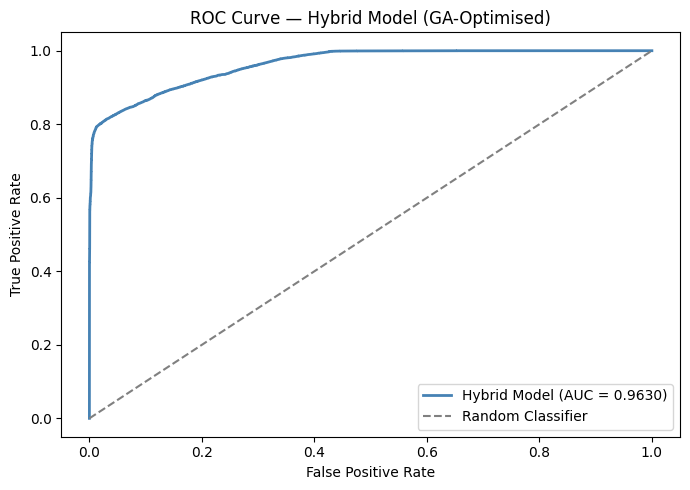

AUC: 0.9630486435213119


In [31]:
y_probs_hybrid = hybrid_model.predict(X_te_sel, verbose=0)

fpr, tpr, _ = roc_curve(y_test, y_probs_hybrid)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"Hybrid Model (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Hybrid Model (GA-Optimised)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("AUC:", roc_auc)

## CELL 13: Final Comparison — Baseline vs Hybrid Model (Test Dataset)

  Baseline Accuracy  (no GA) : 0.8188
  Hybrid   Accuracy  (GA)    : 0.8255
  Improvement                : +0.0067
  ✓ Hybrid model OUTPERFORMED the baseline.


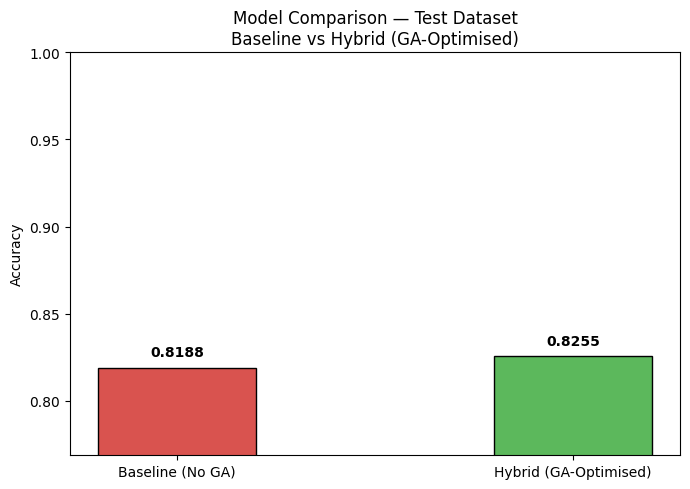

In [32]:
baseline_acc = accuracy_score(y_test, baseline_preds)
hybrid_acc   = accuracy_score(y_test, hybrid_preds)

print("=" * 50)
print(f"  Baseline Accuracy  (no GA) : {baseline_acc:.4f}")
print(f"  Hybrid   Accuracy  (GA)    : {hybrid_acc:.4f}")
print(f"  Improvement                : {hybrid_acc - baseline_acc:+.4f}")
print("=" * 50)

if hybrid_acc > baseline_acc:
    print("  ✓ Hybrid model OUTPERFORMED the baseline.")
else:
    print("  ✗ No improvement observed.")

# Bar chart
labels = ['Baseline (No GA)', 'Hybrid (GA-Optimised)']
values = [baseline_acc, hybrid_acc]
colours = ['#d9534f', '#5cb85c']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=colours, width=0.4, edgecolor='black')
plt.ylim(min(values) - 0.05, 1.0)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha='center', va='bottom', fontweight='bold')

plt.ylabel("Accuracy")
plt.title("Model Comparison — Test Dataset\nBaseline vs Hybrid (GA-Optimised)")
plt.tight_layout()
plt.show()

## CELL 14: GA Convergence Plot

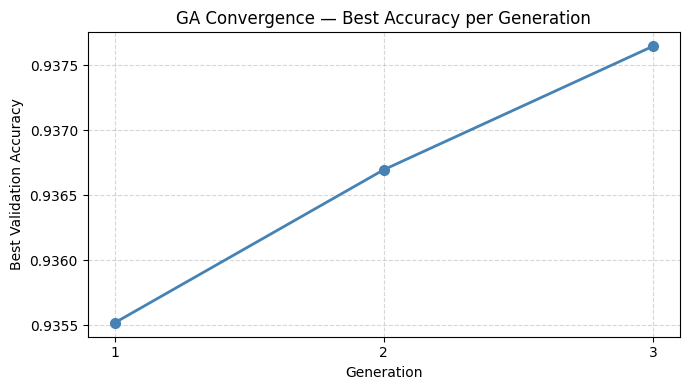

In [33]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, generations + 1), best_per_gen,
         marker='o', color='steelblue', linewidth=2, markersize=7)
plt.xlabel("Generation")
plt.ylabel("Best Validation Accuracy")
plt.title("GA Convergence — Best Accuracy per Generation")
plt.xticks(range(1, generations + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()